# Appendix C — Numerical Analysis Review

**STAT 418 · Computational Data Science** · runnable companion to the
[Numerical Analysis appendix](../../Website/appendices/numerical_analysis.rst).

Most statistical computations cannot be done in closed form. Maximum likelihood
solves nonlinear **score equations**; Bayesian posteriors require intractable
**integrals**; confidence intervals need **roots** of profile-likelihood functions.
Numerical analysis supplies the algorithms that turn these expressions into numbers —
and the error bounds and convergence rates that tell us *when to trust them*. This
notebook is the runnable engine room: it shows **why** the standard algorithms work,
**when** they fail (floating point, saddle points, ill-conditioning), and **how fast**
they converge (linear vs quadratic).

> **Reference / review appendix.** Everything here is the machinery the chapters lean
> on. The *statistical* applications live in the chapters (Newton–Raphson for MLE in
> §3.2, IRLS for GLMs in §3.5, quadrature vs Monte Carlo in §2.1); this appendix is the
> engine under the hood. There are **no external datasets** — every example is a
> self-contained numerical demo, so you can run all of it offline.

## Learning outcomes
By the end you can:
1. Read IEEE-754 `float64` limits off `np.finfo`, predict float **spacing**, and
   recognize / repair **catastrophic cancellation** (quadratic formula, `log1p`/`expm1`).
2. Implement and compare **root finders** — fixed-point iteration (contraction mapping),
   bisection, and Newton — and explain linear vs **quadratic** convergence.
3. Run **gradient descent vs Newton** for an MLE, tie the slow GD rate to the Hessian
   **condition number** $\kappa$, and pick a **quasi-Newton** method by derivative budget.
4. Compute derivatives numerically, balance the **truncation–roundoff** tradeoff to find
   the optimal step $h^\*$, and use the **complex-step** trick to dodge cancellation.
5. Choose between **quadrature** ($O(h^2)$ trapezoid, $O(h^4)$ Simpson, adaptive `quad`)
   and **Monte Carlo** ($O(n^{-1/2})$, dimension-free), and verify the rates empirically.
6. Classify **convergence order** from iterate errors and **diagnose non-convergence**
   (a saddle point that passes every gradient-based stopping rule).

## Section map (review appendix — all sections are core to the toolkit)
| § | Topic | Worked numerical demo |
|---|-------|------------------------|
| C.1 | Floating-point arithmetic | `finfo` + spacing; quadratic-formula cancellation; `log1p`/`expm1` |
| C.2 | Root finding | $x=\cos x$ contraction; bisection vs Newton on $x^3-2$ |
| C.3 | Optimization | Gamma-MLE: GD vs Newton ($\kappa=73$); Normal-MLE method bake-off |
| C.4 | Numerical differentiation | forward/central V-curve; complex-step method |
| C.5 | Numerical integration | trapezoid $O(h^2)$ vs Simpson $O(h^4)$; adaptive `quad`; Monte Carlo |
| C.6 | Convergence & stopping | order estimation; saddle-point diagnosis via the Hessian |
| — | Course connections + exercises | how each tool powers Ch 2/3/5 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate, stats
from scipy.special import logsumexp, gammaln, digamma, polygamma
%matplotlib inline

np.random.seed(418)            # global seed (STYLE.md contract)
# NOTE: examples that mirror the appendix re-seed with default_rng(42) LOCALLY so the
# printed numbers reproduce the webbook's verified outputs exactly.
plt.rcParams.update({
    'figure.figsize': (7.2, 4.2), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#4C72B0', '#C44E52', '#55A868', '#DD8452', '#8172B3'
EPS = np.finfo(float).eps
print('environment ready · numpy', np.__version__, '· machine epsilon =', f'{EPS:.3e}')

environment ready · numpy 1.26.4 · machine epsilon = 2.220e-16


## Section C.1 — Floating-Point Arithmetic

A `float64` stores $(-1)^s \times 1.m \times 2^{e-1023}$: a sign bit, a 52-bit mantissa
$m$, and an 11-bit exponent $e$ — about **15–16 significant decimal digits**. The single
most important consequence: floats are **not uniformly spaced**. Near $x$, the gap to the
next representable float is $\approx |x|\cdot\varepsilon_{\text{mach}}$, where the
**machine epsilon** $\varepsilon_{\text{mach}} = 2^{-52} \approx 2.22\times10^{-16}$ is
the smallest $\varepsilon$ with $\mathrm{fl}(1+\varepsilon)\neq 1$. Relative precision is
roughly constant ($\sim$16 digits); **absolute** precision is fine near 0 and coarse for
large numbers.


In [2]:
# IEEE-754 float64 limits and the linear growth of float spacing with magnitude.
info = np.finfo(float)
print('IEEE 754 double precision (float64)')
print(f'{"Property":>20}  {"Value":>14}')
print('-' * 38)
print(f'{"Machine epsilon":>20}  {info.eps:>14.2e}')
print(f'{"Smallest normal":>20}  {info.tiny:>14.2e}')
print(f'{"Largest finite":>20}  {info.max:>14.2e}')
print(f'{"Mantissa bits":>20}  {info.nmant:>14d}')
print()
print('Float spacing at different magnitudes (gap to the next float):')
print(f'{"x":>10}  {"np.spacing(x)":>16}  {"x * eps_mach":>16}')
print('-' * 46)
fp_x = np.array([1e-10, 1e-5, 1.0, 1e5, 1e10, 1e15])
fp_gap = np.array([np.spacing(x) for x in fp_x])
for x, g in zip(fp_x, fp_gap):
    print(f'{x:>10.0e}  {g:>16.2e}  {x*info.eps:>16.2e}')
print()
print(f'At x=1e15 the gap is {np.spacing(1e15):.3f}: integers above 2^53 ='
      f' {2.0**53:.3e} are NOT all representable.')

IEEE 754 double precision (float64)
            Property           Value
--------------------------------------
     Machine epsilon        2.22e-16
     Smallest normal       2.23e-308
      Largest finite       1.80e+308
       Mantissa bits              52

Float spacing at different magnitudes (gap to the next float):
         x     np.spacing(x)      x * eps_mach
----------------------------------------------
     1e-10          1.29e-26          2.22e-26
     1e-05          1.69e-21          2.22e-21
     1e+00          2.22e-16          2.22e-16
     1e+05          1.46e-11          2.22e-11
     1e+10          1.91e-06          2.22e-06
     1e+15          1.25e-01          2.22e-01

At x=1e15 the gap is 0.125: integers above 2^53 = 9.007e+15 are NOT all representable.


### Catastrophic cancellation

**Catastrophic cancellation** is what happens when you subtract two nearly equal floats:
the leading digits cancel and you are left with the *less significant* (noisier) trailing
digits. The textbook trap is the smaller root of $x^2 - Bx + 1 = 0$, namely
$(B-\sqrt{B^2-4})/2$ — for large $B$, $B$ and $\sqrt{B^2-4}$ agree in their leading
digits. The algebraically equivalent form $2/(B+\sqrt{B^2-4})$ involves **no
subtraction** and stays exact.


In [3]:
# Quadratic formula: x^2 - Bx + 1 = 0.  Naive smaller root vs the cancellation-free form.
print('Quadratic formula  x^2 - Bx + 1 = 0   (smaller root)')
print(f'{"B":>8}  {"Naive root":>20}  {"Stable root":>20}  {"Rel error":>11}')
print('-' * 65)
Bvals = np.array([1e1, 1e2, 1e3, 1e4, 1e6, 1e8])
cancel_relerr = []
for B in Bvals:
    sqrt_d = np.sqrt(B**2 - 4)
    naive = (B - sqrt_d) / 2          # subtracts two nearly-equal numbers -> cancellation
    stable = 2.0 / (B + sqrt_d)       # algebraically identical, no subtraction
    rel = abs(naive - stable) / stable
    cancel_relerr.append(rel)
    print(f'{B:>8.0e}  {naive:>20.15f}  {stable:>20.15f}  {rel:>11.2e}')
cancel_relerr = np.array(cancel_relerr)
print(f'\nAt B=1e8 the naive root loses {100*cancel_relerr[-1]:.0f}% of the answer to'
      ' cancellation; the stable form is exact at every B.')

Quadratic formula  x^2 - Bx + 1 = 0   (smaller root)
       B            Naive root           Stable root    Rel error
-----------------------------------------------------------------
   1e+01     0.101020514433644     0.101020514433644     4.26e-15
   1e+02     0.010001000200049     0.010001000200050     1.22e-13
   1e+03     0.001000001000023     0.001000001000002     2.06e-11
   1e+04     0.000100000001112     0.000100000001000     1.12e-09
   1e+06     0.000001000007614     0.000001000000000     7.61e-06
   1e+08     0.000000007450581     0.000000010000000     2.55e-01

At B=1e8 the naive root loses 25% of the answer to cancellation; the stable form is exact at every B.


### Log-space arithmetic

In likelihood work, products of many small probabilities **underflow** to 0 and
exponentials of large arguments **overflow** to $\infty$. The fix is to work in **log
space**: products become sums ($\log\prod f_i=\sum\log f_i$), ratios become differences,
and $\log L(\theta)$ stays finite even when $L$ is astronomically small. Two specialized
functions dodge cancellation near 1: `np.log1p(x)` $=\log(1+x)$ and `np.expm1(x)` $=e^x-1$,
both accurate for tiny $x$ where the naive forms collapse to exactly 0.


In [4]:
# log1p / expm1 retain information where the naive forms round to exactly 0.
print('Log-space arithmetic near zero')
print(f'{"x":>8}  {"log(1+x)":>22}  {"log1p(x)":>22}  {"Rel diff":>10}')
print('-' * 68)
for x in [1e-1, 1e-5, 1e-10, 1e-15, 1e-16]:
    naive = np.log(1 + x); stable = np.log1p(x)
    rel = abs(naive - stable) / abs(stable) if stable != 0 else 0.0
    print(f'{x:>8.0e}  {naive:>22.16f}  {stable:>22.16f}  {rel:>10.2e}')
print()
print(f'{"x":>8}  {"exp(x)-1":>22}  {"expm1(x)":>22}  {"Rel diff":>10}')
print('-' * 68)
for x in [1e-1, 1e-5, 1e-10, 1e-15, 1e-16]:
    naive = np.exp(x) - 1; stable = np.expm1(x)
    rel = abs(naive - stable) / abs(stable) if stable != 0 else 0.0
    print(f'{x:>8.0e}  {naive:>22.16e}  {stable:>22.16e}  {rel:>10.2e}')
print()
print('At x=1e-16, log(1+x) and exp(x)-1 BOTH return exactly 0 (total loss of input);')
print('log1p / expm1 recover the answer to ~16 digits. Essential near probability 1.')

Log-space arithmetic near zero
       x                log(1+x)                log1p(x)    Rel diff
--------------------------------------------------------------------
   1e-01      0.0953101798043249      0.0953101798043249    7.28e-16
   1e-05      0.0000099999500004      0.0000099999500003    6.55e-12
   1e-10      0.0000000001000000      0.0000000001000000    8.27e-08
   1e-15      0.0000000000000011      0.0000000000000010    1.10e-01
   1e-16      0.0000000000000000      0.0000000000000001    1.00e+00

       x                exp(x)-1                expm1(x)    Rel diff
--------------------------------------------------------------------
   1e-01  1.0517091807564771e-01  1.0517091807564763e-01    7.92e-16
   1e-05  1.0000050000069649e-05  1.0000050000166668e-05    9.70e-12
   1e-10  1.0000000827403710e-10  1.0000000000500000e-10    8.27e-08
   1e-15  1.1102230246251565e-15  1.0000000000000007e-15    1.10e-01
   1e-16  0.0000000000000000e+00  9.9999999999999998e-17    1.00e+00

A

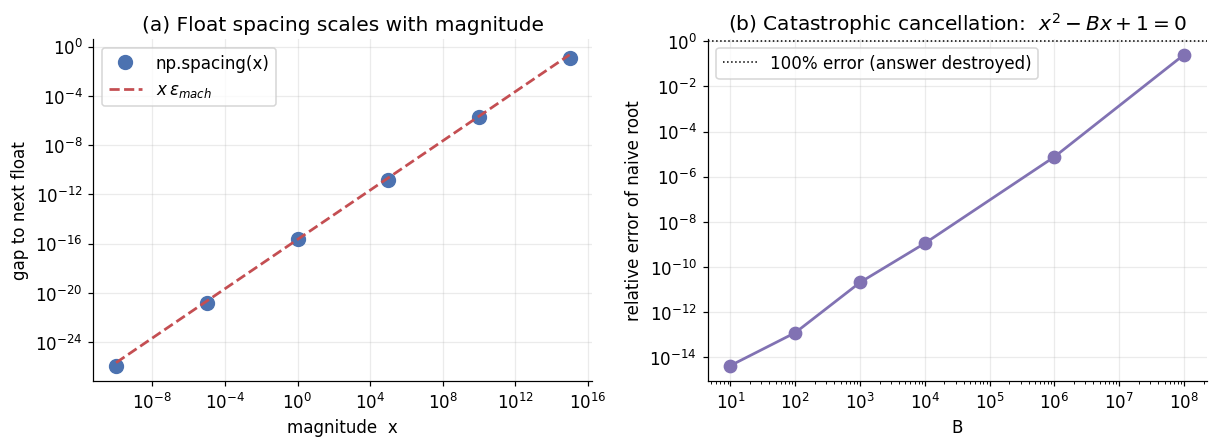

In [5]:
# Figure C.1: (a) float spacing grows linearly with magnitude; (b) cancellation error
# in the quadratic formula grows with B.
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.2, 4.2))
axA.loglog(fp_x, fp_gap, 'o', color=BLUE, ms=9, label='np.spacing(x)')
axA.loglog(fp_x, fp_x * EPS, '--', color=RED, lw=1.8, label=r'$x\,\varepsilon_{mach}$')
axA.set_xlabel('magnitude  x'); axA.set_ylabel('gap to next float')
axA.set_title('(a) Float spacing scales with magnitude'); axA.legend()
axB.loglog(Bvals, cancel_relerr, 'o-', color=PURPLE, lw=1.8, ms=8)
axB.axhline(1.0, color='k', ls=':', lw=1, label='100% error (answer destroyed)')
axB.set_xlabel('B'); axB.set_ylabel('relative error of naive root')
axB.set_title('(b) Catastrophic cancellation:  $x^2-Bx+1=0$'); axB.legend(loc='upper left')
plt.tight_layout(); plt.show()

**Read-out.** Float spacing tracks the line $x\,\varepsilon_{\text{mach}}$ almost
perfectly — absolute precision degrades from $\sim10^{-26}$ near $10^{-10}$ to $0.125$ near
$10^{15}$. The naive smaller-root formula loses **25%** of the answer at $B=10^8$, while
the subtraction-free form is exact everywhere. The rule travels with you all course: when
a formula subtracts nearly equal quantities, find an algebraically equivalent form — or
move to log space — *before* trusting the result. (Welford's stable variance is the same
lesson; see §2.1.)


## Section C.2 — Root Finding

A **fixed point** of $g$ is an $x^\*$ with $g(x^\*)=x^\*$. Many algorithms are just
fixed-point iteration $x_{k+1}=g(x_k)$ — Newton, gradient descent, and IRLS differ only in
the choice of $g$. The **Banach fixed-point theorem** says: if $g$ is a *contraction*
($|g(x)-g(y)|\le L|x-y|$ with $L<1$) on $[a,b]\to[a,b]$, then it has a unique fixed point,
every start converges to it, and the error contracts **linearly**:
$|x_k-x^\*|\le L^k|x_0-x^\*|$. For smooth $g$ the rate is $L=|g'(x^\*)|$. We watch this on
$x=\cos x$.


In [6]:
# Fixed-point iteration x_{k+1} = cos(x_k).  The error ratio converges to L = |g'(x*)|.
x_star = 0.7390851332151607          # the Dottie number, root of x = cos(x)
x = 0.0
print('Fixed-point iteration: x = cos(x)   (x* = 0.739085...)')
print(f'{"k":>3}  {"x_k":>18}  {"|x_k - x*|":>12}  {"ratio":>8}')
print('-' * 46)
prev = abs(x - x_star)
for k in range(13):
    err = abs(x - x_star)
    ratio = (err / prev) if k > 0 else float('nan')
    tag = f'{ratio:>8.4f}' if k > 0 else f'{"--":>8}'
    print(f'{k:>3}  {x:>18.15f}  {err:>12.2e}  {tag}')
    prev = err
    x = np.cos(x)
L = abs(np.sin(x_star))
print(f'\nContraction constant L = |g\'(x*)| = |sin(x*)| = {L:.6f}')
print('Observed ratio -> L: ~6 iterations buy one extra decimal digit (LINEAR).')

Fixed-point iteration: x = cos(x)   (x* = 0.739085...)
  k                 x_k    |x_k - x*|     ratio
----------------------------------------------
  0   0.000000000000000      7.39e-01        --
  1   1.000000000000000      2.61e-01    0.3530
  2   0.540302305868140      1.99e-01    0.7619
  3   0.857553215846393      1.18e-01    0.5960
  4   0.654289790497779      8.48e-02    0.7158
  5   0.793480358742566      5.44e-02    0.6415
  6   0.701368773622757      3.77e-02    0.6934
  7   0.763959682900654      2.49e-02    0.6595
  8   0.722102425026708      1.70e-02    0.6827
  9   0.750417761763761      1.13e-02    0.6673
 10   0.731404042422510      7.68e-03    0.6778
 11   0.744237354900557      5.15e-03    0.6708
 12   0.735604740436347      3.48e-03    0.6755

Contraction constant L = |g'(x*)| = |sin(x*)| = 0.673612
Observed ratio -> L: ~6 iterations buy one extra decimal digit (LINEAR).


### Bisection vs Newton

**Bisection** needs only a sign change $f(a)<0<f(b)$ and continuity: halve the bracket
each step, so $|x_k-x^\*|\le (b-a)/2^k$ — **linear**, rate $1/2$ ($\approx 3.3$ iterations
per digit), and it *always works*. **Newton** linearizes $f$ at each iterate,
$x_{k+1}=x_k - f(x_k)/f'(x_k)$, and converges **quadratically** near a simple root
($|x_{k+1}-x^\*|\le C|x_k-x^\*|^2$) — the number of correct digits roughly *doubles* each
step — but it needs a good start and $f'\neq 0$. We race them to find $\sqrt[3]{2}$.


In [7]:
# Bisection vs Newton on f(x) = x^3 - 2, root = 2^(1/3).
f  = lambda x: x**3 - 2
fp = lambda x: 3 * x**2
root = 2.0 ** (1.0/3.0)

a, b = 1.0, 2.0
bisect_errs = []
for _ in range(20):
    mid = 0.5 * (a + b)
    bisect_errs.append(abs(mid - root))
    if f(mid) * f(a) < 0: b = mid
    else:                 a = mid

x = 2.0
newton_errs = [abs(x - root)]
for _ in range(7):
    x = x - f(x) / fp(x)
    newton_errs.append(abs(x - root))
bisect_errs = np.array(bisect_errs); newton_errs = np.array(newton_errs)

print(f'Root finding: f(x) = x^3 - 2,  x* = 2^(1/3) = {root:.15f}')
print(f'{"iter":>4}  {"bisection |err|":>16}  {"Newton |err|":>16}')
print('-' * 42)
for i in range(8):
    b_str = f'{bisect_errs[i]:>16.2e}'
    n_str = f'{newton_errs[i]:>16.2e}' if i < len(newton_errs) else f'{"converged":>16}'
    print(f'{i:>4}  {b_str}  {n_str}')
print('\nNewton hits machine precision in 6 steps; bisection needs ~27 to reach 1e-8.')
print('brentq (bisection + interpolation) keeps the GUARANTEE while going faster:')
print(f'  scipy.optimize.brentq -> {optimize.brentq(f, 1.0, 2.0):.15f}')

Root finding: f(x) = x^3 - 2,  x* = 2^(1/3) = 1.259921049894873
iter   bisection |err|      Newton |err|
------------------------------------------
   0          2.40e-01          7.40e-01
   1          9.92e-03          2.40e-01
   2          1.15e-01          3.64e-02
   3          5.26e-02          1.01e-03
   4          2.13e-02          8.11e-07
   5          5.70e-03          5.22e-13
   6          2.11e-03          0.00e+00
   7          1.80e-03          0.00e+00

Newton hits machine precision in 6 steps; bisection needs ~27 to reach 1e-8.
brentq (bisection + interpolation) keeps the GUARANTEE while going faster:
  scipy.optimize.brentq -> 1.259921049894854


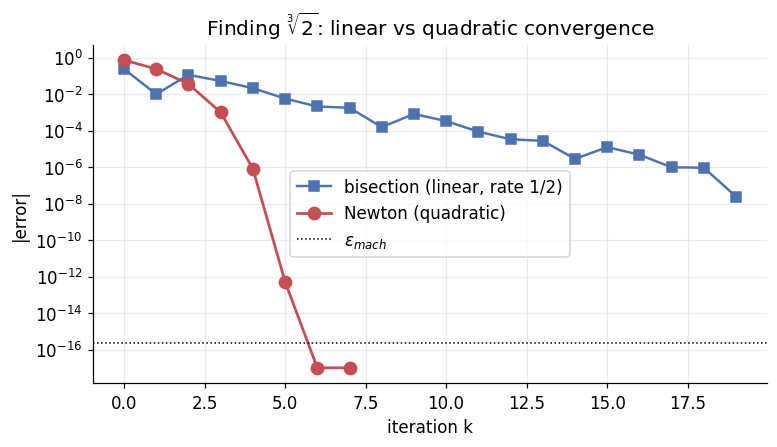

In [8]:
# Figure C.2: error vs iteration (log scale) -- bisection LINEAR vs Newton QUADRATIC.
fig, ax = plt.subplots()
ax.semilogy(range(len(bisect_errs)), bisect_errs, 's-', color=BLUE, lw=1.6, ms=6,
            label='bisection (linear, rate 1/2)')
nz = newton_errs.copy(); nz[nz == 0] = 1e-17        # show the floor on a log axis
ax.semilogy(range(len(nz)), nz, 'o-', color=RED, lw=1.8, ms=8,
            label='Newton (quadratic)')
ax.axhline(EPS, color='k', ls=':', lw=1, label=r'$\varepsilon_{mach}$')
ax.set_xlabel('iteration k'); ax.set_ylabel('|error|')
ax.set_title(r'Finding $\sqrt[3]{2}$: linear vs quadratic convergence')
ax.legend(); plt.tight_layout(); plt.show()

**Read-out.** Bisection's error is a straight line on the log axis — constant slope,
the signature of **linear** convergence — and reaches $10^{-8}$ only after $\sim$20 steps,
but it cannot fail. Newton's error plunges with a *doubling* slope (**quadratic**) and is
at machine precision by step 6. SciPy's `brentq` blends the two: bisection's guarantee with
interpolation's speed. That is exactly the routine §2.3 uses to invert a CDF and §3.2 uses
for a profile-likelihood CI endpoint. Optimization is root finding in disguise — minimizing
$f$ means solving $\nabla f=0$ — which is the next section.


## Section C.3 — Numerical Optimization

Minimizing $f(\theta)$ by **gradient descent**, $\theta_{k+1}=\theta_k-\alpha\nabla
f(\theta_k)$, is a fixed-point iteration whose fixed points are the critical points of $f$.
For a strongly convex $f$ it converges **linearly** at rate
$\big(\tfrac{\kappa-1}{\kappa+1}\big)$, where $\kappa=L/\mu$ is the Hessian **condition
number** (largest/smallest eigenvalue). **Newton's method**,
$\theta_{k+1}=\theta_k-\mathbf H^{-1}\nabla f$, minimizes the local quadratic model, is
**affine-invariant** (immune to conditioning), and converges **quadratically** — at the
price of forming and solving with the Hessian. We see the gap on a real **Gamma MLE**.


In [9]:
# Gamma(alpha, beta) MLE by Newton (exact Hessian) vs gradient descent (step 1/L).
rng = np.random.default_rng(42)            # mirror the appendix seed -> reproducible numbers
n = 50
data = rng.gamma(4.0, 1.0/2.0, n)          # shape 4, rate 2  (scipy 'scale' = 1/rate)
S_log, S = np.sum(np.log(data)), np.sum(data)

def grad_neg(a, b):                         # gradient of the NEGATIVE log-likelihood
    return np.array([-(n*np.log(b) - n*digamma(a) + S_log), -(n*a/b - S)])
def hess_neg(a, b):
    return np.array([[n*polygamma(1, a), -n/b], [-n/b, n*a/b**2]])

# Newton
a_nw, b_nw = 2.0, 1.0
nw_path = [(a_nw, b_nw)]
for _ in range(20):
    step = np.linalg.solve(hess_neg(a_nw, b_nw), grad_neg(a_nw, b_nw))
    a_nw -= step[0]; b_nw -= step[1]
    nw_path.append((a_nw, b_nw))
    if np.linalg.norm(step) < 1e-14: break
a_star, b_star = a_nw, b_nw

# Conditioning of the problem at the MLE
evals = np.linalg.eigvalsh(hess_neg(a_star, b_star))
Lhess, kappa, lr = evals.max(), evals.max()/evals.min(), 1.0/evals.max()

# Gradient descent from the same start
a_gd, b_gd = 2.0, 1.0
gd_path = [(a_gd, b_gd)]
for _ in range(200):
    g = grad_neg(a_gd, b_gd)
    a_gd = max(a_gd - lr*g[0], 0.01); b_gd = max(b_gd - lr*g[1], 0.01)
    gd_path.append((a_gd, b_gd))
nw_path = np.array(nw_path); gd_path = np.array(gd_path)
dist = lambda p: np.hypot(p[0]-a_star, p[1]-b_star)

print(f'Gamma MLE (n={n}): alpha_hat = {a_star:.4f}, beta_hat = {b_star:.4f}')
print(f'Condition number kappa = {kappa:.1f}   |   GD step alpha = 1/L = {lr:.4f}')
print(f'{"iter":>5}  {"GD ||theta-theta*||":>20}  {"Newton ||theta-theta*||":>22}')
print('-' * 51)
for k in [0, 1, 2, 3, 4, 5, 10, 25, 50, 100, 200]:
    gd_e = f'{dist(gd_path[k]):>20.6f}' if k < len(gd_path) else f'{"":>20}'
    nw_e = f'{dist(nw_path[k]):>22.2e}' if k < len(nw_path) else f'{"converged":>22}'
    print(f'{k:>5}  {gd_e}  {nw_e}')
rate = (kappa - 1)/(kappa + 1)
print(f'\nTheoretical GD rate (kappa-1)/(kappa+1) = {rate:.3f} -> '
      f'~{np.log(0.1)/np.log(rate):.0f} iterations per decimal digit.')

Gamma MLE (n=50): alpha_hat = 6.6685, beta_hat = 3.5977
Condition number kappa = 73.3   |   GD step alpha = 1/L = 0.0299
 iter   GD ||theta-theta*||  Newton ||theta-theta*||
---------------------------------------------------
    0              5.342546                5.34e+00
    1              5.083337                3.84e+00
    2              4.862029                1.98e+00
    3              4.664648                5.31e-01
    4              4.452428                3.80e-02
    5              4.283482                1.95e-04
   10              3.013962               converged
   25              2.173839               converged
   50              1.384307               converged
  100              0.628403               converged
  200              0.149146               converged

Theoretical GD rate (kappa-1)/(kappa+1) = 0.973 -> ~84 iterations per decimal digit.


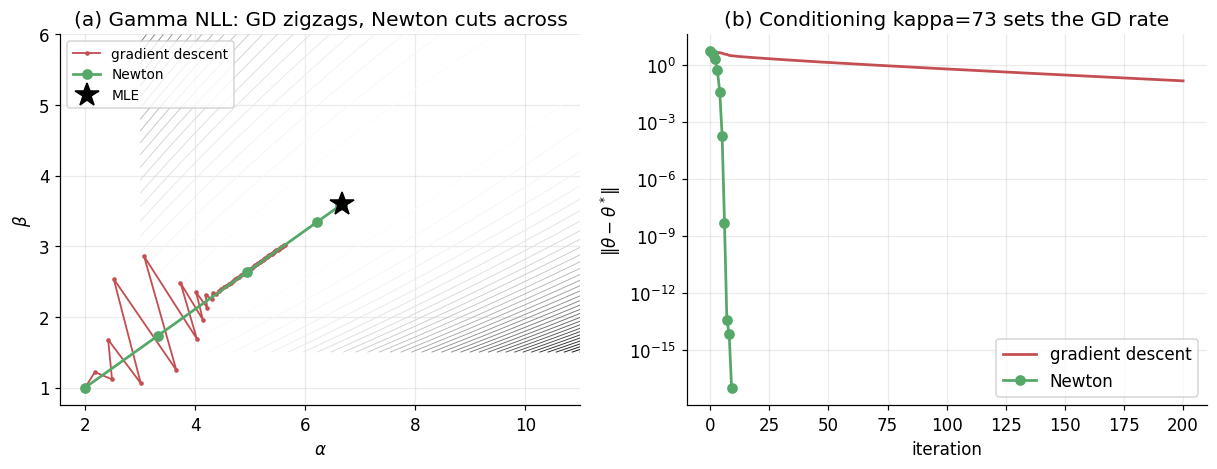

In [10]:
# Figure C.3: (a) NLL contours with both optimizer paths; (b) error vs iteration.
ag = np.linspace(3.0, 11.0, 160); bg = np.linspace(1.5, 6.0, 160)
AA, BB = np.meshgrid(ag, bg)
NLL = -(n*AA*np.log(BB) - n*gammaln(AA) + (AA-1)*S_log - BB*S)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.2, 4.4))
axA.contour(AA, BB, NLL, levels=35, cmap='Greys', linewidths=0.6)
axA.plot(gd_path[:60, 0], gd_path[:60, 1], '.-', color=RED, lw=1.2, ms=4,
         label='gradient descent')
axA.plot(nw_path[:, 0], nw_path[:, 1], 'o-', color=GREEN, lw=1.8, ms=6, label='Newton')
axA.plot([a_star], [b_star], '*', color='k', ms=16, label='MLE')
axA.set_xlabel(r'$\alpha$'); axA.set_ylabel(r'$\beta$')
axA.set_title('(a) Gamma NLL: GD zigzags, Newton cuts across'); axA.legend(loc='upper left', fontsize=9)
gd_err = np.array([dist(p) for p in gd_path]); nw_err = np.array([dist(p) for p in nw_path])
nw_err[nw_err == 0] = 1e-17
axB.semilogy(range(len(gd_err)), gd_err, '-', color=RED, lw=1.8, label='gradient descent')
axB.semilogy(range(len(nw_err)), nw_err, 'o-', color=GREEN, lw=1.8, ms=6, label='Newton')
axB.set_xlabel('iteration'); axB.set_ylabel(r'$\|\theta-\theta^*\|$')
axB.set_title(f'(b) Conditioning kappa={kappa:.0f} sets the GD rate'); axB.legend()
plt.tight_layout(); plt.show()

### Quasi-Newton: trading derivatives for evaluations

Newton needs the full $p\times p$ Hessian each step. **Quasi-Newton** methods (**BFGS**,
and limited-memory **L-BFGS-B** for box constraints) approximate the Hessian from gradient
differences alone, getting *superlinear* convergence without second derivatives.
`scipy.optimize.minimize(method='L-BFGS-B')` is the production MLE workhorse used
throughout §3.2. The tradeoff is sharp: more derivative information $\Rightarrow$ fewer
function evaluations. We fit a **Normal MLE** three ways.


In [11]:
# Normal MLE three ways: Newton-CG (grad+Hess) vs L-BFGS-B (grad) vs Nelder-Mead (none).
rng = np.random.default_rng(42)
ndat = rng.normal(5, 3, 200)

def neg_loglik(p):                          # parameterize (mu, log sigma^2) -> unconstrained
    mu, ls2 = p; s2 = np.exp(ls2); m = len(ndat)
    return m/2*np.log(2*np.pi*s2) + np.sum((ndat - mu)**2)/(2*s2)
def g_norm(p):
    mu, ls2 = p; s2 = np.exp(ls2); m = len(ndat)
    return np.array([-np.sum(ndat - mu)/s2, m/2 - np.sum((ndat - mu)**2)/(2*s2)])
def h_norm(p):
    mu, ls2 = p; s2 = np.exp(ls2)
    return np.array([[len(ndat)/s2, np.sum(ndat - mu)/s2],
                     [np.sum(ndat - mu)/s2, np.sum((ndat - mu)**2)/(2*s2)]])

x0 = [0.0, 0.0]
res_ncg = optimize.minimize(neg_loglik, x0, method='Newton-CG', jac=g_norm, hess=h_norm)
res_lb  = optimize.minimize(neg_loglik, x0, method='L-BFGS-B', jac=g_norm)
res_nm  = optimize.minimize(neg_loglik, x0, method='Nelder-Mead')
print(f'Normal MLE (n=200): closed-form mu = {ndat.mean():.4f}, sigma^2 = {ndat.var():.4f}')
print(f'{"method":>12}  {"derivs":>8}  {"iters":>6}  {"f-evals":>8}  {"mu":>9}  {"sigma^2":>9}')
print('-' * 60)
for name, r, d in [('Newton-CG', res_ncg, 'grad+H'), ('L-BFGS-B', res_lb, 'grad'),
                   ('Nelder-Mead', res_nm, 'none')]:
    print(f'{name:>12}  {d:>8}  {r.nit:>6}  {r.nfev:>8}  {r.x[0]:>9.4f}  {np.exp(r.x[1]):>9.4f}')
print('\nAll three find the same optimum; Nelder-Mead needs ~10x the function evaluations')
print('because it infers the geometry from function VALUES alone (no derivatives).')

Normal MLE (n=200): closed-form mu = 4.9086, sigma^2 = 6.9653
      method    derivs   iters   f-evals         mu    sigma^2
------------------------------------------------------------
   Newton-CG    grad+H      12        14     4.9086     6.9653
    L-BFGS-B      grad      15        16     4.9086     6.9652
 Nelder-Mead      none      82       156     4.9087     6.9652

All three find the same optimum; Nelder-Mead needs ~10x the function evaluations
because it infers the geometry from function VALUES alone (no derivatives).


**Read-out.** The Gamma problem has condition number $\kappa\approx73$: gradient descent
**zigzags** down the elongated valley and still has error $\approx0.15$ after 200 steps,
while Newton — *immune* to conditioning by affine invariance — reaches the MLE
$(\hat\alpha,\hat\beta)\approx(6.67,3.60)$ in **5 steps**. The Normal bake-off makes the
derivative tradeoff concrete: Newton-CG (grad+Hessian) and L-BFGS-B (grad only) both finish
in $\sim$15 iterations, while derivative-free Nelder-Mead burns $\sim$156 function
evaluations for the same answer. Default to L-BFGS-B; reach for Newton when the Hessian is
cheap and conditioning bites.


## Section C.4 — Numerical Differentiation

When analytic derivatives are unavailable we approximate $f'(x)$ from evaluations. The
**forward difference** $\frac{f(x+h)-f(x)}{h}$ has $O(h)$ truncation error; the **central
difference** $\frac{f(x+h)-f(x-h)}{2h}$ has $O(h^2)$ (odd terms cancel). But there is a
catch: shrinking $h$ shrinks *truncation* error while **growing** *roundoff* error
$O(\varepsilon_{\text{mach}}/h)$ from the subtraction. Minimizing the total gives optimal
steps $h^\*\sim\sqrt{\varepsilon_{\text{mach}}}\approx1.5\times10^{-8}$ (forward) and
$h^\*\sim\varepsilon_{\text{mach}}^{1/3}\approx6\times10^{-6}$ (central) — which is why
`epsilon=1e-5` is the default for the numerical Hessians behind §3.3 standard errors.


In [12]:
# The V-shaped error curve: truncation dominates for large h, roundoff for small h.
x0 = 1.0; true_deriv = np.exp(x0)
h_vals = np.array([10.0**(-p) for p in range(1, 17)])
fwd_err, ctr_err, cpx_err = [], [], []
for h in h_vals:
    fwd = (np.exp(x0 + h) - np.exp(x0)) / h
    ctr = (np.exp(x0 + h) - np.exp(x0 - h)) / (2*h)
    cpx = np.imag(np.exp(x0 + 1j*h)) / h           # complex-step: NO subtraction
    fwd_err.append(abs(fwd - true_deriv)); ctr_err.append(abs(ctr - true_deriv))
    cpx_err.append(abs(cpx - true_deriv))
fwd_err, ctr_err, cpx_err = map(np.array, (fwd_err, ctr_err, cpx_err))

print("Differentiating f(x)=e^x at x=1   (true f'(1)=e=2.7182818285)")
print(f'{"h":>8}  {"forward err":>13}  {"central err":>13}  {"complex-step err":>16}')
print('-' * 56)
for h, fe, ce, xe in zip(h_vals, fwd_err, ctr_err, cpx_err):
    print(f'{h:>8.0e}  {fe:>13.2e}  {ce:>13.2e}  {xe:>16.2e}')
print(f'\nbest forward err {fwd_err.min():.1e} at h={h_vals[fwd_err.argmin()]:.0e}'
      f' (~sqrt(eps)={np.sqrt(EPS):.1e})')
print(f'best central err {ctr_err.min():.1e} at h={h_vals[ctr_err.argmin()]:.0e}'
      f' (~eps^(1/3)={EPS**(1/3):.1e})')

Differentiating f(x)=e^x at x=1   (true f'(1)=e=2.7182818285)
       h    forward err    central err  complex-step err
--------------------------------------------------------
   1e-01       1.41e-01       4.53e-03          4.53e-03
   1e-02       1.36e-02       4.53e-05          4.53e-05
   1e-03       1.36e-03       4.53e-07          4.53e-07
   1e-04       1.36e-04       4.53e-09          4.53e-09
   1e-05       1.36e-05       5.86e-11          4.53e-11
   1e-06       1.36e-06       1.63e-10          4.53e-13
   1e-07       1.40e-07       5.86e-11          4.44e-15
   1e-08       6.60e-09       6.60e-09          0.00e+00
   1e-09       2.15e-07       6.60e-09          0.00e+00
   1e-10       1.55e-06       6.73e-07          4.44e-16
   1e-11       3.26e-05       1.04e-05          0.00e+00
   1e-12       4.32e-04       2.10e-04          0.00e+00
   1e-13       4.56e-04       4.56e-04          0.00e+00
   1e-14       9.34e-03       9.34e-03          0.00e+00
   1e-15       3.90e-01   

### The complex-step method

The **complex-step derivative** $f'(x)\approx\dfrac{\mathrm{Im}\,f(x+ih)}{h}$ uses a purely
*imaginary* perturbation. Taylor-expanding, $\mathrm{Im}\,f(x+ih)=hf'(x)+O(h^3)$ — it has
$O(h^2)$ truncation error and, crucially, **no cancellation** because it never subtracts two
real numbers. So it keeps improving as $h\to0$ instead of hitting a roundoff floor. The
only requirement: $f$ must accept complex inputs (no `abs`, no branches). Modern PPLs
(PyMC, JAX) instead use **automatic differentiation** for exact, machine-precision
gradients — the engine that makes HMC/NUTS practical in §5.5.


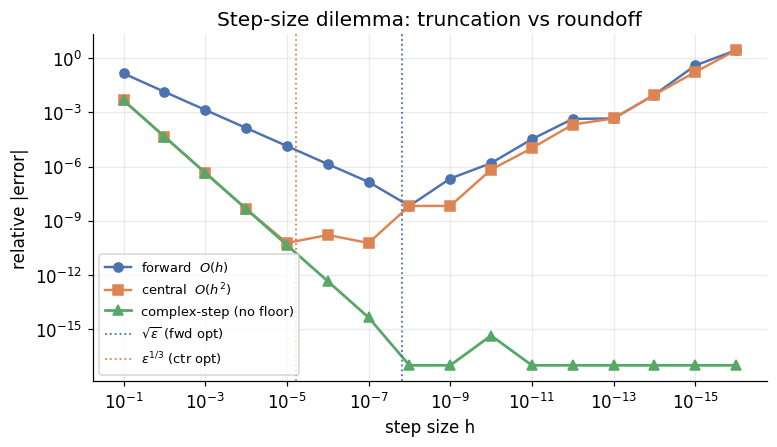

In [13]:
# Figure: forward & central differences show a V (roundoff floor); complex-step does not.
fig, ax = plt.subplots()
ax.loglog(h_vals, fwd_err, 'o-', color=BLUE, lw=1.6, ms=6, label='forward  $O(h)$')
ax.loglog(h_vals, ctr_err, 's-', color=ORANGE, lw=1.6, ms=6, label='central  $O(h^2)$')
cpx_plot = cpx_err.copy(); cpx_plot[cpx_plot == 0] = 1e-17
ax.loglog(h_vals, cpx_plot, '^-', color=GREEN, lw=1.8, ms=7, label='complex-step (no floor)')
ax.axvline(np.sqrt(EPS), color=BLUE, ls=':', lw=1.2, label=r'$\sqrt{\varepsilon}$ (fwd opt)')
ax.axvline(EPS**(1/3), color=ORANGE, ls=':', lw=1.2, label=r'$\varepsilon^{1/3}$ (ctr opt)')
ax.set_xlabel('step size h'); ax.set_ylabel('relative |error|')
ax.set_title('Step-size dilemma: truncation vs roundoff'); ax.legend(fontsize=8.5, loc='lower left')
ax.invert_xaxis(); plt.tight_layout(); plt.show()

**Read-out.** Both finite differences trace the classic **V**: above $h^\*$ truncation
error falls with $h$; below it, cancellation in the numerator makes the error *climb*.
Forward bottoms out near $10^{-8}$ at $h\approx\sqrt\varepsilon$; central does better,
$\sim10^{-11}$ at $h\approx\varepsilon^{1/3}$. The complex-step method has **no floor** —
it reaches machine precision and stays there — because it never subtracts. This is exactly
why a numerical Hessian uses $h\approx10^{-5}$ (near-optimal central), and why
gradient-based MCMC leans on autodiff rather than finite differences.


## Section C.5 — Numerical Integration

Quadrature error follows from how well a piecewise-polynomial interpolant fits the
integrand. On $n$ equally spaced points ($h=(b-a)/(n-1)$): the **trapezoidal** rule
(piecewise linear) has error $O(h^2)$ — doubling $n$ cuts error $4\times$; **Simpson's**
rule (piecewise quadratic) has error $O(h^4)$ — doubling $n$ cuts error $16\times$;
**Gaussian** quadrature converges *exponentially* for analytic integrands. We verify the
trapezoid/Simpson rates by doubling $n$ and reading the error ratios.


In [14]:
# Verify O(h^2) (trapezoid) and O(h^4) (Simpson) on integral of exp(-x^2) over [0,2].
f_int = lambda x: np.exp(-x**2)
a_i, b_i = 0.0, 2.0
exact = integrate.quad(f_int, a_i, b_i)[0]
print('Quadrature convergence:  integral of exp(-x^2) on [0, 2]')
print(f'exact (adaptive quad) = {exact:.10f}')
print(f'{"n":>5}  {"trap err":>11}  {"Simp err":>11}  {"trap ratio":>11}  {"Simp ratio":>11}')
print('-' * 56)
ns = [5, 9, 17, 33, 65, 129]; trap_e, simp_e = [], []
prev_t = prev_s = None
for nn in ns:
    xg = np.linspace(a_i, b_i, nn); yg = f_int(xg)
    et = abs(np.trapz(yg, xg) - exact); es = abs(integrate.simpson(yg, x=xg) - exact)
    trap_e.append(et); simp_e.append(es)
    if prev_t is None:
        print(f'{nn:>5}  {et:>11.2e}  {es:>11.2e}  {"--":>11}  {"--":>11}')
    else:
        print(f'{nn:>5}  {et:>11.2e}  {es:>11.2e}  {prev_t/et:>11.1f}  {prev_s/es:>11.1f}')
    prev_t, prev_s = et, es
trap_e, simp_e = np.array(trap_e), np.array(simp_e)
print('\nTrap ratio -> 4 = 2^2 (confirms O(h^2));  Simpson ratio -> 16 = 2^4 (confirms O(h^4)).')

Quadrature convergence:  integral of exp(-x^2) on [0, 2]
exact (adaptive quad) = 0.8820813908
    n     trap err     Simp err   trap ratio   Simp ratio
--------------------------------------------------------
    5     1.46e-03     2.69e-04           --           --
    9     3.78e-04     1.59e-05          3.9         16.9
   17     9.51e-05     9.94e-07          4.0         16.0
   33     2.38e-05     6.21e-08          4.0         16.0
   65     5.96e-06     3.88e-09          4.0         16.0
  129     1.49e-06     2.43e-10          4.0         16.0

Trap ratio -> 4 = 2^2 (confirms O(h^2));  Simpson ratio -> 16 = 2^4 (confirms O(h^4)).


### Adaptive quadrature and the Monte Carlo alternative

`scipy.integrate.quad` is **adaptive Gaussian quadrature**: it estimates the error on each
subinterval and recursively subdivides only where the integrand is hard, spending
evaluations where they matter. For a single 1-D integral with sharp features it is almost
always the right tool. But it does not scale: a $d$-dimensional grid with $m$ points per
axis costs $m^d$ evaluations. **Monte Carlo** converges at $O(n^{-1/2})$ *independent of
dimension* — slow in 1-D, unbeatable in high dimensions (the crossover is around
$d\approx3$–$5$). That tradeoff is the whole reason §2.1 leans on Monte Carlo.


In [15]:
# Adaptive quad on a multi-scale integrand: 231 evals for 1e-9 accuracy.
def multi_peak(x):
    return np.exp(-100*(x-0.3)**2) + 0.5*np.exp(-1000*(x-0.7)**2) + 0.1
result, err_est, info = integrate.quad(multi_peak, 0, 1, full_output=True, limit=100)
print('Adaptive quad on a multi-scale integrand:')
print(f'  result = {result:.10f}   est. error = {err_est:.2e}')
print(f'  function evaluations = {info["neval"]}   subintervals = {info["last"]}')
for npts in [21, 101, 1001]:
    xg = np.linspace(0, 1, npts)
    print(f'  trapezoid (n={npts:>4}): {np.trapz(multi_peak(xg), xg):.10f}'
          f'  error = {abs(np.trapz(multi_peak(xg), xg) - result):.2e}')

# Monte Carlo error rate: estimate the SAME integral; RMSE shrinks like 1/sqrt(n).
rng = np.random.default_rng(42)
print('\nMonte Carlo for the same integral (mean of f over U(0,1)):')
mc_n = np.array([10**k for k in range(1, 7)]); mc_rmse = []
for nn in mc_n:
    ests = [multi_peak(rng.random(nn)).mean() for _ in range(200)]   # 200 replicate runs
    mc_rmse.append(np.sqrt(np.mean((np.array(ests) - result)**2)))
mc_rmse = np.array(mc_rmse)
print(f'{"n":>9}  {"RMSE":>11}  {"RMSE * sqrt(n)":>15}')
print('-' * 38)
for nn, rm in zip(mc_n, mc_rmse):
    print(f'{nn:>9}  {rm:>11.2e}  {rm*np.sqrt(nn):>15.4f}')
print('RMSE * sqrt(n) is ~constant -> the O(n^-1/2) Monte Carlo rate (dimension-free).')

Adaptive quad on a multi-scale integrand:
  result = 0.3052683835   est. error = 2.15e-09
  function evaluations = 231   subintervals = 6
  trapezoid (n=  21): 0.3063485748  error = 1.08e-03
  trapezoid (n= 101): 0.3052683221  error = 6.14e-08
  trapezoid (n=1001): 0.3052683828  error = 6.17e-10

Monte Carlo for the same integral (mean of f over U(0,1)):


        n         RMSE   RMSE * sqrt(n)
--------------------------------------
       10     1.01e-01           0.3194
      100     3.12e-02           0.3124
     1000     9.60e-03           0.3036
    10000     3.25e-03           0.3245
   100000     1.01e-03           0.3195
  1000000     2.83e-04           0.2833
RMSE * sqrt(n) is ~constant -> the O(n^-1/2) Monte Carlo rate (dimension-free).


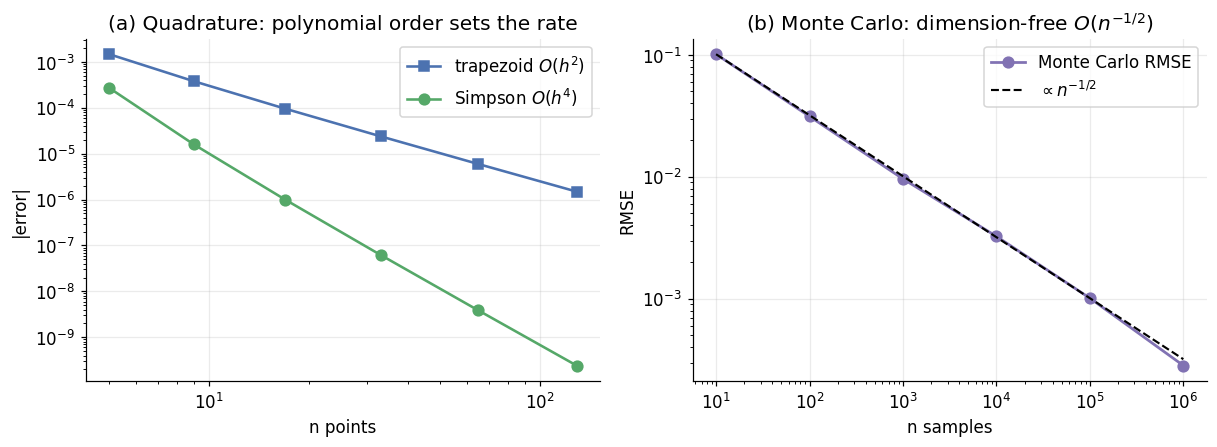

In [16]:
# Figure: (a) quadrature error vs n (trap O(h^2) vs Simpson O(h^4));
#         (b) Monte Carlo RMSE vs n with the n^-1/2 reference line.
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.2, 4.2))
axA.loglog(ns, trap_e, 's-', color=BLUE, lw=1.7, ms=7, label='trapezoid $O(h^2)$')
axA.loglog(ns, simp_e, 'o-', color=GREEN, lw=1.7, ms=7, label="Simpson $O(h^4)$")
axA.set_xlabel('n points'); axA.set_ylabel('|error|')
axA.set_title('(a) Quadrature: polynomial order sets the rate'); axA.legend()
axB.loglog(mc_n, mc_rmse, 'o-', color=PURPLE, lw=1.8, ms=7, label='Monte Carlo RMSE')
ref = mc_rmse[0] * np.sqrt(mc_n[0]) / np.sqrt(mc_n)
axB.loglog(mc_n, ref, '--', color='k', lw=1.4, label=r'$\propto n^{-1/2}$')
axB.set_xlabel('n samples'); axB.set_ylabel('RMSE')
axB.set_title('(b) Monte Carlo: dimension-free $O(n^{-1/2})$'); axB.legend()
plt.tight_layout(); plt.show()

**Read-out.** The doubling experiment nails the theory: trapezoid error falls by a factor
of **4** ($=2^2$) per doubling, Simpson by **16** ($=2^4$). Adaptive `quad` hits $10^{-9}$
on the multi-scale integrand with only **231** evaluations — the trapezoid needs $\sim$1000
points and gives no error estimate. Monte Carlo's $\text{RMSE}\times\sqrt n$ stays flat,
confirming the $O(n^{-1/2})$ rate that *ignores dimension* — slow here, but the only game in
town for the high-dimensional posterior expectations of Part III.


## Section C.6 — Convergence & Stopping Criteria

We can read an algorithm's **convergence order** straight off its error sequence. A
sequence has **linear** convergence with rate $r\in(0,1)$ if $|e_{k+1}|\le r|e_k|$ (error
shrinks by a constant fraction), and **quadratic** convergence if $|e_{k+1}|\le C|e_k|^2$
(correct digits roughly double). A handy diagnostic: $p \approx \log|e_{k+1}|/\log|e_k|$
estimates the order — near 1 is linear, near 2 is quadratic. We run **the same problem**
($x=\cos x$) two ways to expose two orders.


In [17]:
# Same root x* of x=cos(x), two algorithms: fixed-point (linear) vs Newton (quadratic).
x_star = 0.7390851332151607
# Fixed-point g(x)=cos(x)
x = 0.0; fp_errors = [abs(x - x_star)]
for _ in range(30):
    x = np.cos(x); fp_errors.append(abs(x - x_star))
# Newton on f(x)=x-cos(x)
x = 0.0; nw_errors = [abs(x - x_star)]
for _ in range(7):
    x = x - (x - np.cos(x)) / (1 + np.sin(x)); nw_errors.append(abs(x - x_star))

print('Newton on f(x) = x - cos(x):  log-ratio -> 2 (quadratic)')
print(f'{"k":>3}  {"|e_k|":>12}  {"|e_{k+1}|/|e_k|":>16}  {"log ratio":>10}')
print('-' * 48)
for k in range(len(nw_errors) - 1):
    e0, e1 = nw_errors[k], nw_errors[k+1]
    if e0 > 0 and e1 > 0:
        lr = np.log(e1)/np.log(e0) if abs(np.log(e0)) > 0.01 else float('nan')
        print(f'{k:>3}  {e0:>12.2e}  {e1/e0:>16.6f}  {lr:>10.2f}')
    else:
        print(f'{k:>3}  {e0:>12.2e}  {"-- (converged)":>16}')
print('\nFixed-point g(x) = cos(x):  ratio -> L = |sin(x*)| (linear)')
print(f'{"k":>3}  {"|e_k|":>12}  {"|e_{k+1}|/|e_k|":>16}')
print('-' * 34)
for k in [0, 5, 10, 15, 20, 25]:
    print(f'{k:>3}  {fp_errors[k]:>12.2e}  {fp_errors[k+1]/fp_errors[k]:>16.6f}')
print(f'\nFixed-point ratio -> L = |sin(x*)| = {abs(np.sin(x_star)):.4f}. Same problem,'
      ' same start: order alone explains 5 Newton steps vs 25+ fixed-point steps.')

Newton on f(x) = x - cos(x):  log-ratio -> 2 (quadratic)
  k         |e_k|   |e_{k+1}|/|e_k|   log ratio
------------------------------------------------
  0      7.39e-01          0.353024        4.44
  1      2.61e-01          0.043228        3.34
  2      1.13e-02          0.002461        2.34
  3      2.78e-05          0.000006        2.14
  4      1.70e-10    -- (converged)
  5      0.00e+00    -- (converged)
  6      0.00e+00    -- (converged)

Fixed-point g(x) = cos(x):  ratio -> L = |sin(x*)| (linear)
  k         |e_k|   |e_{k+1}|/|e_k|
----------------------------------
  0      7.39e-01          0.353024
  5      5.44e-02          0.693376
 10      7.68e-03          0.670767
 15      1.06e-03          0.674004
 20      1.47e-04          0.673558
 25      2.04e-05          0.673620

Fixed-point ratio -> L = |sin(x*)| = 0.6736. Same problem, same start: order alone explains 5 Newton steps vs 25+ fixed-point steps.


### Stopping criteria, and diagnosing non-convergence

Every iteration needs a stop rule. **Absolute change** $\|\theta_{k+1}-\theta_k\|<\epsilon$
is scale-dependent; **relative change** is scale-invariant and usually preferred;
**gradient norm** $\|\nabla f\|<\epsilon$ tests first-order optimality directly (SciPy's
`gtol`). The pitfalls: stopping on a *plateau* far from the optimum, a tolerance tighter
than $\varepsilon_{\text{mach}}$ (no information left), or silently hitting max-iterations.
The sharpest trap: **a gradient-based stop cannot tell a minimum from a saddle**. We
illustrate with Newton landing exactly on a saddle of
$f(x,y)=x^4/4-x^2/2+y^2/2$, then catch it with the Hessian.


In [18]:
# Newton converges to a SADDLE; only the Hessian eigenvalues reveal the problem.
grad_f = lambda x, y: np.array([x**3 - x, y])
hess_f = lambda x, y: np.array([[3*x**2 - 1, 0.0], [0.0, 1.0]])
x, y = 0.1, 0.3
print('Newton on f(x,y) = x^4/4 - x^2/2 + y^2/2   (start (0.1, 0.3))')
print(f'{"k":>3}  {"x":>12}  {"y":>12}  {"||grad f||":>12}')
print('-' * 44)
for k in range(5):
    g = grad_f(x, y)
    print(f'{k:>3}  {x:>12.8f}  {y:>12.8f}  {np.linalg.norm(g):>12.2e}')
    step = np.linalg.solve(hess_f(x, y), g); x -= step[0]; y -= step[1]
print(f'\nConverged to ({x:.8f}, {y:.8f}),  ||grad f|| = {np.linalg.norm(grad_f(x, y)):.2e}')
eigs = np.linalg.eigvalsh(hess_f(x, y))
print(f'Hessian eigenvalues at the solution: [{eigs[0]:.4f}, {eigs[1]:.4f}]')
verdict = 'SADDLE POINT (a negative eigenvalue)' if np.any(eigs < 0) else 'confirmed minimum'
print(f'Diagnosis: {verdict}.  The gradient is exactly 0, so a gradient stop is fooled;')
print('the true minima are at (+/-1, 0) with f = -0.25. For an MLE (we MAXIMIZE ell),')
print('a POSITIVE Hessian eigenvalue at the reported theta means a saddle, not a maximum.')

Newton on f(x,y) = x^4/4 - x^2/2 + y^2/2   (start (0.1, 0.3))
  k             x             y    ||grad f||
--------------------------------------------
  0    0.10000000    0.30000000      3.16e-01
  1   -0.00206186    0.00000000      2.06e-03
  2    0.00000002    0.00000000      1.75e-08
  3   -0.00000000    0.00000000      9.93e-24
  4    0.00000000    0.00000000      0.00e+00

Converged to (0.00000000, 0.00000000),  ||grad f|| = 0.00e+00
Hessian eigenvalues at the solution: [-1.0000, 1.0000]
Diagnosis: SADDLE POINT (a negative eigenvalue).  The gradient is exactly 0, so a gradient stop is fooled;
the true minima are at (+/-1, 0) with f = -0.25. For an MLE (we MAXIMIZE ell),
a POSITIVE Hessian eigenvalue at the reported theta means a saddle, not a maximum.


**Read-out.** Newton drove $\|\nabla f\|$ to exactly 0 — and parked on a **saddle**, not a
minimum. Every gradient-based stopping rule signed off; only the **Hessian eigenvalue**
$[-1, +1]$ exposes the mixed curvature. The course habit this earns: after any MLE
"converges," check the curvature. We maximize $\ell(\theta)$, so the Hessian of $\ell$
should be **negative definite** at a true maximum; a positive eigenvalue is the tell that
the optimizer found a saddle. (Same logic powers the convergence-order check above.)


## How these tools power the course

Every numerical method here is load-bearing somewhere in STAT 418:

| Numerical tool | This appendix | Course use |
|----------------|---------------|------------|
| Floating-point stability (`log1p`, `logsumexp`) | C.1 | §2.3 inverse-CDF, §2.6 importance weights, Welford variance §2.1 |
| Root finding (`brentq`) | C.2 | §2.3 inverse CDF, §3.2 profile-likelihood CI endpoints |
| Newton–Raphson / Fisher scoring | C.3 | §3.2 MLE, §3.5 IRLS for GLMs |
| Gradient descent / leapfrog | C.3 | §5.5 HMC integrator step size |
| Numerical differentiation (central, $h\approx10^{-5}$) | C.4 | §3.3 numerical Hessian for standard errors |
| Quadrature vs Monte Carlo | C.5 | §2.1 the full crossover comparison |
| Convergence order, condition number | C.6 | §3.2 quadratic convergence, §3.4 QR vs normal equations |

The thread tying them together: pick an algorithm $\Rightarrow$ know its **convergence
order** (how fast) $\Rightarrow$ respect the **floating-point** floor (how accurate) $\Rightarrow$
verify with a **diagnostic** (Hessian curvature, error ratios, an error estimate). That is
exactly the discipline the modeling chapters assume.


## Exercises

Work each before expanding the solution. All are self-contained numerical demos.


**Exercise 1 (§C.1 floating point).** (a) Compute $(1-\cos x)/x^2\to\tfrac12$ both naively
and via the stable form $2\sin^2(x/2)/x^2$ for $x\in\{10^{-1},10^{-3},10^{-5},10^{-7},
10^{-8},10^{-9}\}$. Where does the naive form fail? (b) Show why
`np.log(np.sum(np.exp([1000,1001,1002])))` overflows and fix it with `logsumexp`.


In [19]:
# Solution 1.
print('(a) (1 - cos x)/x^2  -> 1/2:')
print(f'{"x":>8}  {"naive":>22}  {"stable":>22}  {"naive rel err":>13}')
print('-' * 70)
for x in [1e-1, 1e-3, 1e-5, 1e-7, 1e-8, 1e-9]:
    naive = (1 - np.cos(x)) / x**2
    stable = 2 * np.sin(x/2)**2 / x**2
    print(f'{x:>8.0e}  {naive:>22.16e}  {stable:>22.16e}  {abs(naive-0.5)/0.5:>13.2e}')
print('  Naive loses ALL digits by x~1e-8: cos(x) rounds to 1.0, so 1-cos = 0 exactly.')
print('  Stable form holds 0.5 throughout (no subtraction of near-equal numbers).')
print()
z = np.array([1000, 1001, 1002])
print('(b) log(sum(exp([1000,1001,1002]))):')
print(f'  naive  = {np.log(np.sum(np.exp(z)))}   (exp(1000) overflows float64)')
print(f'  logsumexp = {logsumexp(z):.6f}')
print(f'  check 1002 + log(e^-2+e^-1+1) = {1002 + np.log(np.exp(-2)+np.exp(-1)+1):.6f}')

(a) (1 - cos x)/x^2  -> 1/2:
       x                   naive                  stable  naive rel err
----------------------------------------------------------------------
   1e-01  4.9958347219741783e-01  4.9958347219742333e-01       8.33e-04
   1e-03  4.9999995832550326e-01  4.9999995833333472e-01       8.33e-08
   1e-05  5.0000004137018539e-01  4.9999999999583328e-01       8.27e-08
   1e-07  4.9960036108132050e-01  4.9999999999999961e-01       7.99e-04
   1e-08  0.0000000000000000e+00  5.0000000000000000e-01       1.00e+00
   1e-09  0.0000000000000000e+00  5.0000000000000000e-01       1.00e+00
  Naive loses ALL digits by x~1e-8: cos(x) rounds to 1.0, so 1-cos = 0 exactly.
  Stable form holds 0.5 throughout (no subtraction of near-equal numbers).

(b) log(sum(exp([1000,1001,1002]))):
  naive  = inf   (exp(1000) overflows float64)
  logsumexp = 1002.407606
  check 1002 + log(e^-2+e^-1+1) = 1002.407606


/tmp/ipykernel_116493/945663143.py:14: RuntimeWarning: overflow encountered in exp
  print(f'  naive  = {np.log(np.sum(np.exp(z)))}   (exp(1000) overflows float64)')


**Exercise 2 (§C.2 root finding for a CI).** Draw $n=50$ from $\text{Exp}(\lambda=2)$ with
`default_rng(42)`. The 95% profile-likelihood CI endpoints solve
$h(\lambda)=2[\ell(\hat\lambda)-\ell(\lambda)]-\chi^2_{1,0.95}=0$. Find both endpoints by
**bisection** (count iterations) and by **`brentq`**, then compare to the exact
chi-squared CI from the pivot $2\lambda\sum X_i\sim\chi^2_{2n}$.


In [20]:
# Solution 2.
rng = np.random.default_rng(42)
n = 50; data = rng.exponential(1/2, n); sum_x = data.sum()
lam_hat = n / sum_x
loglik = lambda lam: n*np.log(lam) - lam*sum_x
chi2_c = stats.chi2.ppf(0.95, 1)
h = lambda lam: 2*(loglik(lam_hat) - loglik(lam)) - chi2_c
print(f'Exp data: n={n}, sum_x={sum_x:.4f}, MLE lam_hat = n/sum_x = {lam_hat:.6f}')
def bisect_count(a, b):
    it = 0
    while (b - a) > 1e-8:
        mid = 0.5*(a + b)
        if h(mid)*h(a) < 0: b = mid
        else:               a = mid
        it += 1
    return 0.5*(a + b), it
lo_b, it_lo = bisect_count(0.5, lam_hat); hi_b, it_hi = bisect_count(lam_hat, 5.0)
lo_br = optimize.brentq(h, 0.5, lam_hat); hi_br = optimize.brentq(h, lam_hat, 5.0)
lo_ex = stats.chi2.ppf(0.025, 2*n)/(2*sum_x); hi_ex = stats.chi2.ppf(0.975, 2*n)/(2*sum_x)
print(f'  bisection 95% CI = [{lo_b:.6f}, {hi_b:.6f}]  ({it_lo}, {it_hi} iters)')
print(f'  brentq    95% CI = [{lo_br:.6f}, {hi_br:.6f}]')
print(f'  exact chi^2 CI   = [{lo_ex:.6f}, {hi_ex:.6f}]')
print('  Profile-LR and exact agree to ~2 decimals; root-finding is the ONLY route when')
print('  no exact pivot exists (Gamma shape, mixtures, GLMs).')

Exp data: n=50, sum_x=20.8974, MLE lam_hat = n/sum_x = 2.392642
  bisection 95% CI = [1.789254, 3.118475]  (28, 28 iters)
  brentq    95% CI = [1.789254, 3.118475]
  exact chi^2 CI   = [1.775865, 3.099936]
  Profile-LR and exact agree to ~2 decimals; root-finding is the ONLY route when
  no exact pivot exists (Gamma shape, mixtures, GLMs).


**Exercise 3 (§C.3 GD vs Newton).** Draw $n=100$ from $N(5,9)$ with `default_rng(42)`.
Fit the $(\mu,\sigma^2)$ MLE by gradient descent ($\alpha=0.001$) and by Newton from
$(3,3)$. Report the iteration counts and estimate each method's convergence order.


In [21]:
# Solution 3.
rng = np.random.default_rng(42)
n = 100; data = rng.normal(5, 3, n)
theta_star = np.array([data.mean(), data.var()])
def gN(p):
    mu, s2 = p
    return np.array([-np.sum(data - mu)/s2, n/(2*s2) - np.sum((data - mu)**2)/(2*s2**2)])
def hN(p):
    mu, s2 = p
    return np.array([[n/s2, np.sum(data - mu)/s2**2],
                     [np.sum(data - mu)/s2**2, -n/(2*s2**2) + np.sum((data - mu)**2)/s2**3]])
# Gradient descent
th = np.array([3.0, 3.0]); gd_err = [np.linalg.norm(th - theta_star)]; gd_it = 10000
for k in range(10000):
    nt = th - 0.001*gN(th); nt[1] = max(nt[1], 0.01)
    rc = np.linalg.norm(nt - th)/np.linalg.norm(th); th = nt
    gd_err.append(np.linalg.norm(th - theta_star))
    if rc < 1e-8: gd_it = k + 1; break
# Newton
th = np.array([3.0, 3.0]); nw_err = [np.linalg.norm(th - theta_star)]; nw_it = 50
for k in range(50):
    step = np.linalg.solve(hN(th), gN(th)); nt = th - step; nt[1] = max(nt[1], 0.01)
    rc = np.linalg.norm(step)/np.linalg.norm(th); th = nt
    nw_err.append(np.linalg.norm(th - theta_star))
    if rc < 1e-12: nw_it = k + 1; break
print(f'MLE: mu_hat = {theta_star[0]:.4f}, sigma2_hat = {theta_star[1]:.4f}')
print(f'  gradient descent (alpha=0.001): {gd_it} iterations')
print(f'  Newton:                          {nw_it} iterations')
print('  Newton order estimate (last steps):')
for k in range(max(0, len(nw_err)-4), len(nw_err)-1):
    e0, e1 = nw_err[k], nw_err[k+1]
    if e0 > 1e-15 and e1 > 1e-15:
        print(f'    k={k}: |e|={e0:.2e}, order ~ {np.log(e1)/np.log(e0):.2f}')
print('  GD ratio ~0.99 (linear, slow); Newton order ~2 (quadratic) -> ~9 vs thousands of steps.')

MLE: mu_hat = 4.8492, sigma2_hat = 5.3748
  gradient descent (alpha=0.001): 5838 iterations
  Newton:                          9 iterations
  Newton order estimate (last steps):
    k=6: |e|=4.74e-04, order ~ 2.13
    k=7: |e|=8.34e-08, order ~ 2.06
  GD ratio ~0.99 (linear, slow); Newton order ~2 (quadratic) -> ~9 vs thousands of steps.


**Exercise 4 (§C.6 diagnose a saddle).** The function
$f(x,y)=x^4/4-x^2/2+y^4/4-y^2/2$ has 9 critical points. Enumerate them, classify each by
its Hessian eigenvalues, and confirm Newton from $(0.1,0.3)$ lands on a **maximum** (not a
minimum) — the cautionary tale of gradient-only stopping.


In [22]:
# Solution 4.
f4 = lambda x, y: x**4/4 - x**2/2 + y**4/4 - y**2/2
g4 = lambda x, y: np.array([x**3 - x, y**3 - y])
H4 = lambda x, y: np.array([[3*x**2 - 1, 0.0], [0.0, 3*y**2 - 1]])
print('Critical points (x^3-x=0, y^3-y=0 -> x,y in {-1,0,1}):')
for xc in (-1, 0, 1):
    for yc in (-1, 0, 1):
        ev = np.linalg.eigvalsh(H4(xc, yc))
        kind = 'minimum' if np.all(ev > 0) else 'maximum' if np.all(ev < 0) else 'saddle'
        print(f'  ({xc:>2},{yc:>2}): eigs=[{ev[0]:>2.0f},{ev[1]:>2.0f}]  f={f4(xc,yc):+.2f}  -> {kind}')
x, y = 0.1, 0.3
for _ in range(8):
    g = g4(x, y)
    if np.linalg.norm(g) < 1e-14: break
    step = np.linalg.solve(H4(x, y), g); x -= step[0]; y -= step[1]
ev = np.linalg.eigvalsh(H4(x, y))
kind = 'minimum' if np.all(ev > 0) else 'maximum' if np.all(ev < 0) else 'saddle'
print(f'\nNewton from (0.1, 0.3) -> ({x:.4f}, {y:.4f}), f={f4(x,y):.4f}, '
      f'eigs=[{ev[0]:.2f}, {ev[1]:.2f}] -> {kind}!')
print('Gradient norm is ~0 at ALL nine points; only the Hessian distinguishes them.')

Critical points (x^3-x=0, y^3-y=0 -> x,y in {-1,0,1}):
  (-1,-1): eigs=[ 2, 2]  f=-0.50  -> minimum
  (-1, 0): eigs=[-1, 2]  f=-0.25  -> saddle
  (-1, 1): eigs=[ 2, 2]  f=-0.50  -> minimum
  ( 0,-1): eigs=[-1, 2]  f=-0.25  -> saddle
  ( 0, 0): eigs=[-1,-1]  f=+0.00  -> maximum
  ( 0, 1): eigs=[-1, 2]  f=-0.25  -> saddle
  ( 1,-1): eigs=[ 2, 2]  f=-0.50  -> minimum
  ( 1, 0): eigs=[-1, 2]  f=-0.25  -> saddle
  ( 1, 1): eigs=[ 2, 2]  f=-0.50  -> minimum

Newton from (0.1, 0.3) -> (0.0000, 0.0000), f=0.0000, eigs=[-1.00, -1.00] -> maximum!
Gradient norm is ~0 at ALL nine points; only the Hessian distinguishes them.


## Summary

| Quantity | Key fact | This appendix's demo |
|----------|----------|----------------------|
| Machine epsilon | $\varepsilon_{\text{mach}}=2^{-52}\approx2.22\times10^{-16}$ | float spacing $\approx x\,\varepsilon$ |
| Catastrophic cancellation | avoid subtracting near-equal floats | quadratic root: 25% error at $B=10^8$ |
| Log-space safety | `log1p`/`expm1`/`logsumexp` near 0 and $\infty$ | naive forms hit exactly 0 at $10^{-16}$ |
| Contraction mapping | converges iff $L=|g'(x^\*)|<1$, **linear** | $x=\cos x$, ratio $\to0.674$ |
| Bisection | $O(2^{-k})$, always works | $\sqrt[3]2$ in $\sim$20 steps |
| Newton | **quadratic**, needs good start | $\sqrt[3]2$ in 6 steps |
| Condition number $\kappa$ | GD rate $\tfrac{\kappa-1}{\kappa+1}$ | Gamma MLE $\kappa=73$: 200 GD vs 5 Newton |
| Quasi-Newton | superlinear, gradient-only | L-BFGS-B $\approx$ Newton-CG, $\ll$ Nelder-Mead |
| Finite differences | $O(h)$/$O(h^2)$ + roundoff $O(\varepsilon/h)$ | V-curve; $h^\*\approx\sqrt\varepsilon,\varepsilon^{1/3}$ |
| Complex-step | $O(h^2)$, no cancellation floor | error $\to0$ monotonically |
| Quadrature | trap $O(h^2)$, Simpson $O(h^4)$ | ratios $\to4,16$; adaptive `quad` |
| Monte Carlo | $O(n^{-1/2})$, **dimension-free** | $\text{RMSE}\sqrt n$ flat |
| Convergence order | $p\approx\log e_{k+1}/\log e_k$ | $\to1$ (FP) vs $\to2$ (Newton) |
| Saddle diagnosis | check Hessian eigenvalues | gradient-0 saddle caught |

**The discipline.** Choose an algorithm, know its convergence *order* (how fast), respect
the floating-point *floor* (how accurate), and *verify* with a diagnostic (Hessian
curvature, error ratios, an error estimate). Every modeling chapter — MLE in Chapter 3,
MCMC in Chapter 5, Monte Carlo in Chapter 2 — runs on exactly this engine.
